In [26]:
import sys
sys.path.insert(0, "/users/eleves-a/2025/iuliia.korotkova/VLM_probing")

from PIL import Image
from src.extraction.extract import MODEL_REGISTRY
from src.steering.steer import steer_and_generate, SteeringManager, _generate, sweep_alpha

In [2]:
import os
os.environ["HF_HOME"] = "/Data/iuliia.korotkova/huggingface_cache"

In [3]:
!echo $HF_HOME

/Data/iuliia.korotkova/huggingface_cache


In [4]:
# Load model
model_tag = "llava15"
registry_entry = MODEL_REGISTRY[model_tag]
model_id = registry_entry["default_id"]
model, processor = registry_entry["loader"](model_id)

probes_dir = "/Data/iuliia.korotkova/VLM_probing/spatial/llava15/probes"

/users/eleves-a/2025/iuliia.korotkova/VLM_probing/venv-extract/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading checkpoint shards: 100%|██████████| 3/3 [00:02<00:00,  1.29it/s]
Some parameters are on the meta device because they were offloaded to the cpu.
Some kwargs in processor config are unused and will not have any effect: num_additional_image_tokens. 


In [5]:
prompt = "The spatial relationship of gray triangle to cyan square is"
image_path = "/users/eleves-a/2025/iuliia.korotkova/VLM_probing/data/raw/spatial/images/spatial_01309.png"
image = Image.open(image_path).convert("RGB")

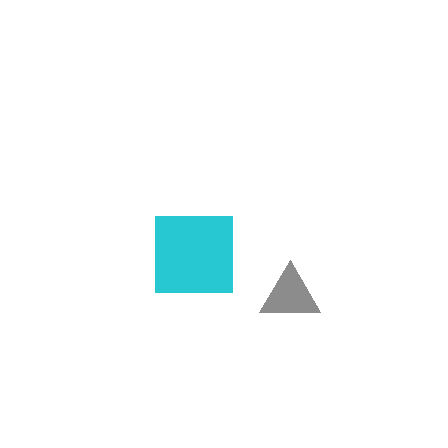

In [6]:
image

In [7]:
baseline_output = _generate(model, processor, model_tag, image, prompt, 50)

In [8]:
baseline_output

"The spatial relationship between the gray triangle and the cyan square is that the triangle is positioned above the square. This arrangement creates a visually interesting contrast between the two shapes, with the triangle's darker color and the square's l"

In [11]:
with SteeringManager.from_probes(
    model, model_tag, probes_dir,
    layers=[32],
    target_class="left_of", alpha=5.0, when="prefill",
):
    output = _generate(model, processor, model_tag, image, prompt, 50)

In [10]:
output

'The image shows a small square (represented by a blue color) next to a larger triangle (represented by a gray color). The square is positioned to the left of the triangle, and they are both located in the upper-'

In [12]:
output

"The spatial relationship between the gray triangle and the cyan square is that the triangle is positioned above the square. This arrangement creates a visually interesting contrast between the two shapes, with the triangle's darker color and the square's l"

In [13]:
with SteeringManager.from_probes(
    model, model_tag, probes_dir,
    layers=[32],
    target_class="right_of", alpha=5.0, when="prefill",
):
    output = _generate(model, processor, model_tag, image, prompt, 50)
    
output

"The spatial relationship between the gray triangle and the cyan square is that the triangle is positioned above the square. This arrangement creates a visually interesting contrast between the two shapes, with the triangle's darker color and the square's l"

In [14]:
with SteeringManager.from_probes(
    model, model_tag, probes_dir,
    layers=[32],
    target_class="left_of", alpha=5.0, when="all",
):
    output = _generate(model, processor, model_tag, image, prompt, 50)
    
output

'The spatial relationship between the gray triangle and the cyan square is that they are both positioned on the same plane, but the triangle is located to the left of the square. This arrangement creates a visually interesting contrast between the two shapes, as'

In [15]:
with SteeringManager.from_probes(
    model, model_tag, probes_dir,
    layers=[32],
    target_class="right_of", alpha=5.0, when="all",
):
    output = _generate(model, processor, model_tag, image, prompt, 50)
    
output

'The spatial relationship of the gray triangle to the cyan square is that the triangle is located above the square. This arrangement can be seen in the image, where the gray triangle is positioned above the blue square. The triangle and square are both part'

In [16]:
with SteeringManager.from_probes(
    model, model_tag, probes_dir,
    layers=[32],
    target_class="above", alpha=5.0, when="all",
):
    output = _generate(model, processor, model_tag, image, prompt, 50)
    
output

'The spatial relationship between the gray triangle and the cyan square is that the triangle is positioned above the square.'

In [17]:
with SteeringManager.from_probes(
    model, model_tag, probes_dir,
    layers=[32],
    target_class="below", alpha=5.0, when="all",
):
    output = _generate(model, processor, model_tag, image, prompt, 50)
    
output

'The spatial relationship of the gray triangle to the blue square is that the triangle is positioned below the square. This arrangement creates a visual contrast between the blue square and the gray triangle, making the blue square stand out more prominently. The blue'

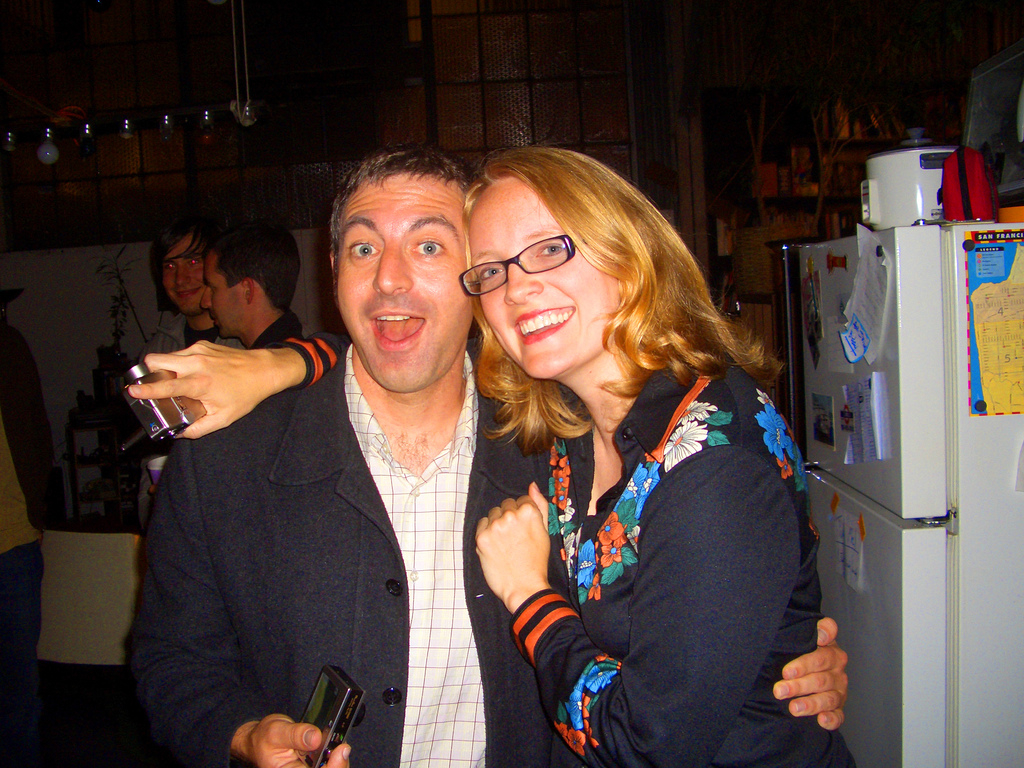

In [19]:
prompt = "Where does the woman stand compared to the man?"
image_path = "/users/eleves-a/2025/iuliia.korotkova/VLM_probing/data/test/img1.jpg"
image = Image.open(image_path).convert("RGB")
image

In [23]:
baseline_output = _generate(model, processor, model_tag, image, prompt, 50)
baseline_output

'The woman stands next to the man, with her arm around him.'

In [20]:
with SteeringManager.from_probes(
    model, model_tag, probes_dir,
    layers=[32],
    target_class="left_of", alpha=5.0, when="all",
):
    output = _generate(model, processor, model_tag, image, prompt, 50)
    
output

'The woman stands behind the man, both of them posing for a picture.'

In [21]:
with SteeringManager.from_probes(
    model, model_tag, probes_dir,
    layers=[32],
    target_class="left_of", alpha=5.0, when="all",
    source_class="right_of", strategy="contrast"
):
    output = _generate(model, processor, model_tag, image, prompt, 50)
    
output

"The woman stands between the man' before they pose for the picture."

In [22]:
with SteeringManager.from_probes(
    model, model_tag, probes_dir,
    layers=[32],
    target_class="right_of", alpha=5.0, when="all",
):
    output = _generate(model, processor, model_tag, image, prompt, 50)
    
output

'The woman stands behind the man, with her arms around him.'

In [24]:
with SteeringManager.from_probes(
    model, model_tag, probes_dir,
    layers=[32],
    target_class="above", alpha=5.0, when="all",
):
    output = _generate(model, processor, model_tag, image, prompt, 50)
    
output

'The woman stands next to the man, with her arm around him.'

In [28]:
with SteeringManager.from_probes(
    model, model_tag, probes_dir,
    layers=list(range(20, 33)),
    target_class="left_of", alpha=5.0, when="all",
):
    output = _generate(model, processor, model_tag, image, prompt, 50)
    
output

'before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before'

In [29]:
layers = list(range(20, 33))

results = sweep_alpha(
    model, processor, model_tag,
    image, prompt,
    probes_dir, layers,
    target_class="left_of",
    # source_class=args.source,
    alphas=[0.5, 1, 3, 5],
    strategy="push",
    when="all",
    max_new_tokens=50,
)

  α=   0.5  →  The woman stands behind the man, with her arms around him.
  α=   1.0  →  The woman stands between the man'Left and Right.
  α=   3.0  →  Left before left before.

esso.ЪЪЪЪЪЪЪЪЪЪЪ. (before before before before before before before before before before before before before before before before before before before before before before before before before before before before
  α=   5.0  →  before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before


In [30]:
results

[{'alpha': 0.5,
  'output': 'The woman stands behind the man, with her arms around him.'},
 {'alpha': 1, 'output': "The woman stands between the man'Left and Right."},
 {'alpha': 3,
  'output': 'Left before left before.\n\nesso.ЪЪЪЪЪЪЪЪЪЪЪ. (before before before before before before before before before before before before before before before before before before before before before before before before before before before before'},
 {'alpha': 5,
  'output': 'before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before before'}]

In [32]:
layers = [32]

results = sweep_alpha(
    model, processor, model_tag,
    image, prompt,
    probes_dir, layers,
    target_class="left_of",
    # source_class=args.source,
    alphas=[1, 3, 5, 8, 10],
    strategy="push",
    when="all",
    max_new_tokens=50,
)

results

  α=   1.0  →  The woman stands behind the man, with her arms around him.
  α=   3.0  →  The woman stands behind the man, with her arms around him.
  α=   5.0  →  The woman stands behind the man, both of them posing for a picture.
  α=   8.0  →  The woman is standing behind the man, both of them are smiling and posing for the camera.
  α=  10.0  →  The woman is standing between the man's arms, which suggests that they are both close to each other and possibly posing for a picture.


[{'alpha': 1,
  'output': 'The woman stands behind the man, with her arms around him.'},
 {'alpha': 3,
  'output': 'The woman stands behind the man, with her arms around him.'},
 {'alpha': 5,
  'output': 'The woman stands behind the man, both of them posing for a picture.'},
 {'alpha': 8,
  'output': 'The woman is standing behind the man, both of them are smiling and posing for the camera.'},
 {'alpha': 10,
  'output': "The woman is standing between the man's arms, which suggests that they are both close to each other and possibly posing for a picture."}]